In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

In [28]:
df = pd.read_csv("/content/impaired_driver_text_dataset.csv")
print(df.head())

X = df['text']
y = df['label']
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

                                                text     label
0  I almost missed the signal because I lost focu...  impaired
1  My reaction time feels very slow near the high...  impaired
2  My eyes keep closing on the road late at night...  impaired
3  Struggling to keep the car in lane late at nig...  impaired
4  Following all traffic rules today during the r...      safe


In [29]:
print(df.duplicated().sum())
print(df.shape)

0
(1000, 2)


In [30]:
#Logistic Regression
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_score = accuracy_score(y_test, lr_pred)

print(lr_score)

1.0


In [31]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

nb_score = accuracy_score(y_test, nb_pred)

print(nb_score)

0.99


In [32]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_score = accuracy_score(y_test, dt_pred)

print(dt_score)

0.985


In [33]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_score = accuracy_score(y_test, rf_pred)

print(rf_score)

1.0


In [34]:
svm = LinearSVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_score = accuracy_score(y_test, svm_pred)

print(svm_score)

1.0


In [35]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'Decision Tree',
        'Random Forest',
        'SVM'
    ],

    'Accuracy': [
        lr_score,
        nb_score,
        dt_score,
        rf_score,
        svm_score
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression     1.000
1          Naive Bayes     0.990
2        Decision Tree     0.985
3        Random Forest     1.000
4                  SVM     1.000


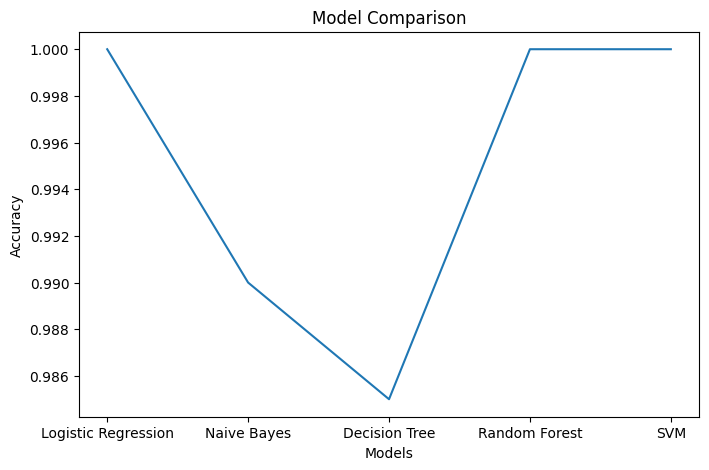

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(results['Model'], results['Accuracy'])

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()